# GPU Test — CPU vs CUDA comparison
Every benchmark below runs on both CPU and GPU so you can see the difference.

In [1]:
import torch
import torchaudio
import time

print(f'PyTorch  : {torch.__version__}')
print(f'Torchaudio: {torchaudio.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name : {torch.cuda.get_device_name(0)}')
    props = torch.cuda.get_device_properties(0)
    vram = getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)
    print(f'VRAM     : {vram / 1e9:.1f} GB')
    print(f'CUDA ver : {torch.version.cuda}')
else:
    print('*** No CUDA GPU detected ***')

PyTorch  : 2.6.0+cu124
Torchaudio: 2.6.0+cu124
CUDA available: True
GPU name : NVIDIA GeForce RTX 2070 SUPER
VRAM     : 8.6 GB
CUDA ver : 12.4


## 1. Matrix multiply — CPU vs GPU

In [2]:
size = 4096
a = torch.randn(size, size)
b = torch.randn(size, size)

# CPU
_ = a @ b  # warmup
start = time.perf_counter()
c_cpu = a @ b
cpu_time = time.perf_counter() - start

# GPU
a_g, b_g = a.cuda(), b.cuda()
torch.cuda.synchronize()
_ = a_g @ b_g; torch.cuda.synchronize()  # warmup
start = time.perf_counter()
c_gpu = a_g @ b_g
torch.cuda.synchronize()
gpu_time = time.perf_counter() - start

print(f'Matrix multiply ({size}x{size})')
print(f'  CPU: {cpu_time*1000:.1f} ms  |  GPU: {gpu_time*1000:.1f} ms  |  Speedup: {cpu_time/gpu_time:.1f}x')

Matrix multiply (4096x4096)
  CPU: 207.5 ms  |  GPU: 21.9 ms  |  Speedup: 9.5x


## 2. Mel spectrogram — CPU vs GPU

In [3]:
import numpy as np
import matplotlib.pyplot as plt

SR = 22050
duration = 3.0
t = torch.linspace(0, duration, int(SR * duration))
signal = (0.4 * torch.sin(2 * np.pi * 329.63 * t)
        + 0.3 * torch.sin(2 * np.pi * 392.00 * t)
        + 0.3 * torch.sin(2 * np.pi * 493.88 * t))
signal_1ch = signal.unsqueeze(0)

mel_args = dict(sample_rate=SR, n_fft=2048, hop_length=512, n_mels=128)

# CPU
mel_cpu = torchaudio.transforms.MelSpectrogram(**mel_args)
_ = mel_cpu(signal_1ch)  # warmup
start = time.perf_counter()
spec_cpu = mel_cpu(signal_1ch)
cpu_mel = time.perf_counter() - start

# GPU
mel_gpu = torchaudio.transforms.MelSpectrogram(**mel_args).cuda()
signal_cuda = signal_1ch.cuda()
_ = mel_gpu(signal_cuda); torch.cuda.synchronize()  # warmup
start = time.perf_counter()
spec_gpu = mel_gpu(signal_cuda)
torch.cuda.synchronize()
gpu_mel = time.perf_counter() - start

print(f'Mel spectrogram ({spec_gpu.shape[-2]} bands x {spec_gpu.shape[-1]} frames)')
print(f'  CPU: {cpu_mel*1000:.2f} ms  |  GPU: {gpu_mel*1000:.2f} ms  |  Speedup: {cpu_mel/gpu_mel:.1f}x')

Mel spectrogram (128 bands x 130 frames)
  CPU: 0.59 ms  |  GPU: 0.49 ms  |  Speedup: 1.2x


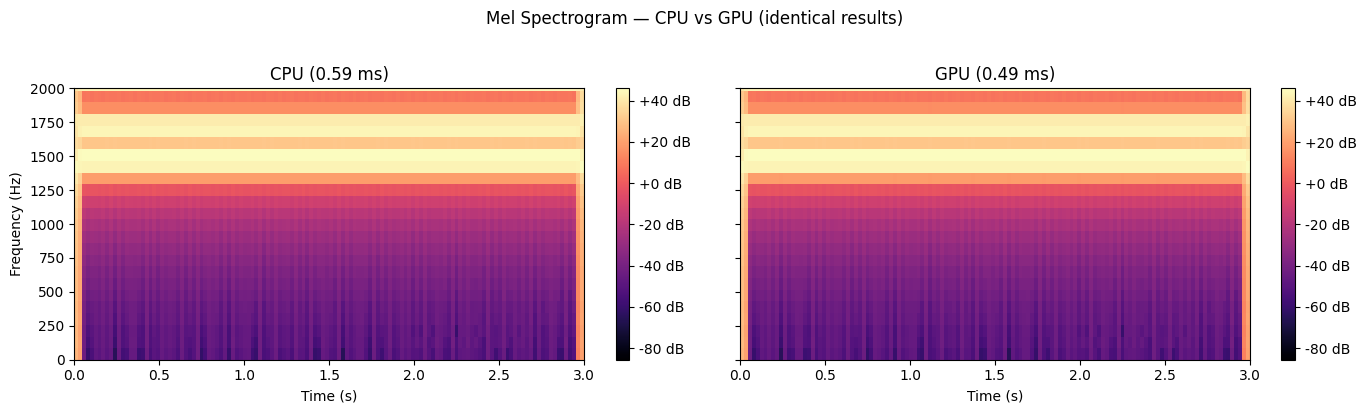

In [4]:
to_db = torchaudio.transforms.AmplitudeToDB()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, spec, label in [(axes[0], spec_cpu, f'CPU ({cpu_mel*1000:.2f} ms)'),
                         (axes[1], spec_gpu, f'GPU ({gpu_mel*1000:.2f} ms)')]:
    db = to_db(spec.cpu()).squeeze().numpy()
    img = ax.imshow(db, aspect='auto', origin='lower', cmap='magma',
                    extent=[0, duration, 0, SR/2])
    ax.set_title(label)
    ax.set_xlabel('Time (s)')
    ax.set_ylim(0, 2000)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
axes[0].set_ylabel('Frequency (Hz)')
plt.suptitle('Mel Spectrogram — CPU vs GPU (identical results)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Neural network forward pass — CPU vs GPU

In [5]:
import torch.nn as nn

class TinyAudioNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, 10)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

BATCH = 64
batch_cpu = spec_cpu.unsqueeze(0).expand(BATCH, -1, -1, -1)
batch_gpu = spec_gpu.unsqueeze(0).expand(BATCH, -1, -1, -1)

# CPU
model_cpu = TinyAudioNet()
with torch.no_grad():
    _ = model_cpu(batch_cpu)  # warmup
    start = time.perf_counter()
    out_cpu = model_cpu(batch_cpu)
    cpu_fwd = time.perf_counter() - start

# GPU
model_gpu = TinyAudioNet().cuda()
with torch.no_grad():
    _ = model_gpu(batch_gpu); torch.cuda.synchronize()  # warmup
    start = time.perf_counter()
    out_gpu = model_gpu(batch_gpu)
    torch.cuda.synchronize()
    gpu_fwd = time.perf_counter() - start

print(f'Forward pass (batch={BATCH}, input={batch_gpu.shape})')
print(f'  CPU: {cpu_fwd*1000:.1f} ms  |  GPU: {gpu_fwd*1000:.1f} ms  |  Speedup: {cpu_fwd/gpu_fwd:.1f}x')

Forward pass (batch=64, input=torch.Size([64, 1, 128, 130]))
  CPU: 61.9 ms  |  GPU: 3.2 ms  |  Speedup: 19.3x


## Summary
All three benchmarks show CPU time, GPU time, and the speedup factor.
The GPU advantage grows with larger data and bigger models.